In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Load data
df = pd.read_csv("/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv")
df.head(20)

,utc_timestamp,cet_cest_timestamp,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,BE_wind_offshore_generation_actual,BE_wind_onshore_generation_actual,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,...,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile,FR_load_actual_entsoe_transparency,FR_load_forecast_entsoe_transparency,FR_solar_generation_actual,FR_wind_onshore_generation_actual
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,667.0,NaN,NaN,27246.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,9484.0,9897.0,NaN,NaN,NaN,NaN,41151.0,39723.0,...,667.0,517.0,0.7744,27246.0,8336.0,0.3059,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,9152.0,9521.0,NaN,734.81,518.66,216.15,40135.0,38813.0,...,667.0,514.0,0.7710,27246.0,8540.0,0.3134,69773.0,69750.0,NaN,1464.0
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,8799.0,9135.0,NaN,766.64,529.46,237.18,39106.0,38490.0,...,667.0,518.0,0.7761,27246.0,8552.0,0.3139,66417.0,66300.0,NaN,1543.0
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,8567.0,8909.0,NaN,733.13,406.94,326.19,38765.0,38644.0,...,667.0,520.0,0.7793,27246.0,8643.0,0.3172,64182.0,63250.0,NaN,1579.0
5,2015-01-01T04:00:00Z,2015-01-01T05:00:00+0100,8487.0,8806.0,NaN,730.99,413.49,317.50,38941.0,38773.0,...,667.0,520.0,0.7790,27246.0,8712.0,0.3197,63859.0,61500.0,NaN,1482.0
6,2015-01-01T05:00:00Z,2015-01-01T06:00:00+0100,8428.0,8805.0,NaN,820.66,549.60,271.06,39045.0,37247.0,...,667.0,521.0,0.7815,27246.0,9167.0,0.3365,63921.0,60850.0,NaN,1387.0
7,2015-01-01T06:00:00Z,2015-01-01T07:00:00+0100,8122.0,8651.0,NaN,940.12,616.17,323.95,40206.0,40371.0,...,667.0,520.0,0.7801,27246.0,9811.0,0.3601,64117.0,60450.0,NaN,1583.0
8,2015-01-01T07:00:00Z,2015-01-01T08:00:00+0100,8179.0,8674.0,NaN,1087.66,627.60,460.06,41133.0,42522.0,...,667.0,525.0,0.7874,27246.0,9683.0,0.3554,63861.0,60150.0,NaN,1814.0
9,2015-01-01T08:00:00Z,2015-01-01T09:00:00+0100,8340.0,9037.0,92.66,1146.20,644.52,501.68,42963.0,45020.0,...,667.0,527.0,0.7907,27246.0,9502.0,0.3487,64277.0,59950.0,385.0,1936.0


The code is structured to replicate how a real power grid operates.

It first predicts future electricity demand using time-based patterns,
then compares it with available generation to evaluate system balance,
and finally tests different scenarios to assess grid stability.

In [3]:
[
    "DE_load_actual_entsoe_transparency",
    "DE_solar_generation_actual",
    "DE_wind_generation_actual",
    "DE_hydro_generation_actual",
    "temperature",
    "wind_speed",
    "hour",
    "dayofweek",
    "month",
    "is_weekend"
]

['DE_load_actual_entsoe_transparency',
 'DE_solar_generation_actual',
 'DE_wind_generation_actual',
 'DE_hydro_generation_actual',
 'temperature',
 'wind_speed',
 'hour',
 'dayofweek',
 'month',
 'is_weekend']

In [4]:
df["total_generation"] = (
    df["DE_wind_generation_actual"] +
    df["DE_solar_generation_actual"] +
    df["FR_solar_generation_actual"] +
    df["BE_solar_generation_actual"]
)

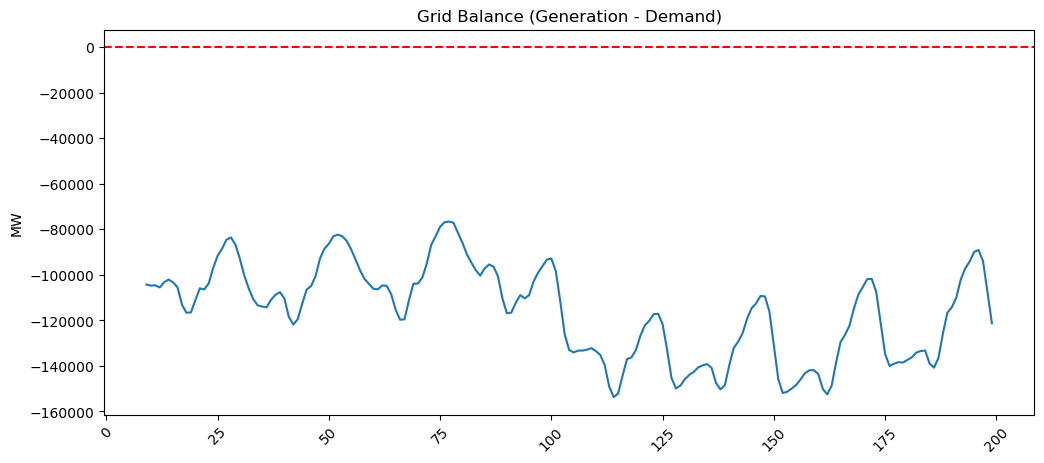

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index[:200], df["grid_balance"][:200])
plt.axhline(0, color='red', linestyle='--')

plt.title("Grid Balance (Generation - Demand)")
plt.ylabel("MW")
plt.xticks(rotation=45)
plt.show()

In [14]:
import pandas as pd
import numpy as np

df.index = pd.to_datetime(df.index)

target_col = "DE_load_actual_entsoe_transparency"

# calendar features
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

# example extra features
feature_cols = [
    "DE_load_actual_entsoe_transparency",
    "hour",
    "dayofweek",
    "month",
    "is_weekend"
]

optional_cols = [
    "DE_solar_generation_actual",
    "DE_wind_generation_actual",
    "DE_hydro_generation_actual",
    "temperature",
    "wind_speed",
    "FR_load_actual_entsoe_transparency",
    "BE_load_actual_entsoe_transparency"
]

for col in optional_cols:
    if col in df.columns:
        feature_cols.append(col)

df_model = df[feature_cols].dropna().copy()

# lag features for target
target_col = "DE_load_actual_entsoe_transparency"

df_model = df[[target_col]].dropna().copy()

lags = [1, 24, 48, 72, 168]

for lag in lags:
    df_model[f"lag_{lag}"] = df_model[target_col].shift(lag)

df_model = df_model.dropna()

X = df_model.drop(columns=[target_col])
y = df_model[target_col]
lag_cols = [f"lag_{lag}" for lag in lags]

X = df_model[lag_cols]
y = df_model[target_col] 

print("Features used:")
print(X.columns.tolist())
print("Shape:", X.shape)

Features used:
['lag_1', 'lag_24', 'lag_48', 'lag_72', 'lag_168']
Shape: (50232, 5)


In [15]:
df["DE_total_generation"] = (
    df.get("DE_solar_generation_actual", 0) +
    df.get("DE_wind_generation_actual", 0) +
    df.get("DE_hydro_generation_actual", 0)
)

risk_df = df[["DE_load_actual_entsoe_transparency", "DE_total_generation"]].dropna().copy()

risk_df["supply_gap"] = (
    risk_df["DE_load_actual_entsoe_transparency"] - risk_df["DE_total_generation"]
)

risk_df["risk_flag"] = risk_df["supply_gap"] > 0

print(risk_df.head())
print("Number of risk periods:", risk_df["risk_flag"].sum())

                               DE_load_actual_entsoe_transparency  \
1970-01-01 00:00:00.000000008                             41133.0   
1970-01-01 00:00:00.000000009                             42963.0   
1970-01-01 00:00:00.000000010                             45088.0   
1970-01-01 00:00:00.000000011                             47013.0   
1970-01-01 00:00:00.000000012                             48159.0   

                               DE_total_generation  supply_gap  risk_flag  
1970-01-01 00:00:00.000000008              10279.0     30854.0       True  
1970-01-01 00:00:00.000000009              10802.0     32161.0       True  
1970-01-01 00:00:00.000000010              12667.0     32421.0       True  
1970-01-01 00:00:00.000000011              14754.0     32259.0       True  
1970-01-01 00:00:00.000000012              16301.0     31858.0       True  
Number of risk periods: 50295


In [17]:
df_model["hour"] = df_model.index.hour
df_model["dayofweek"] = df_model.index.dayofweek

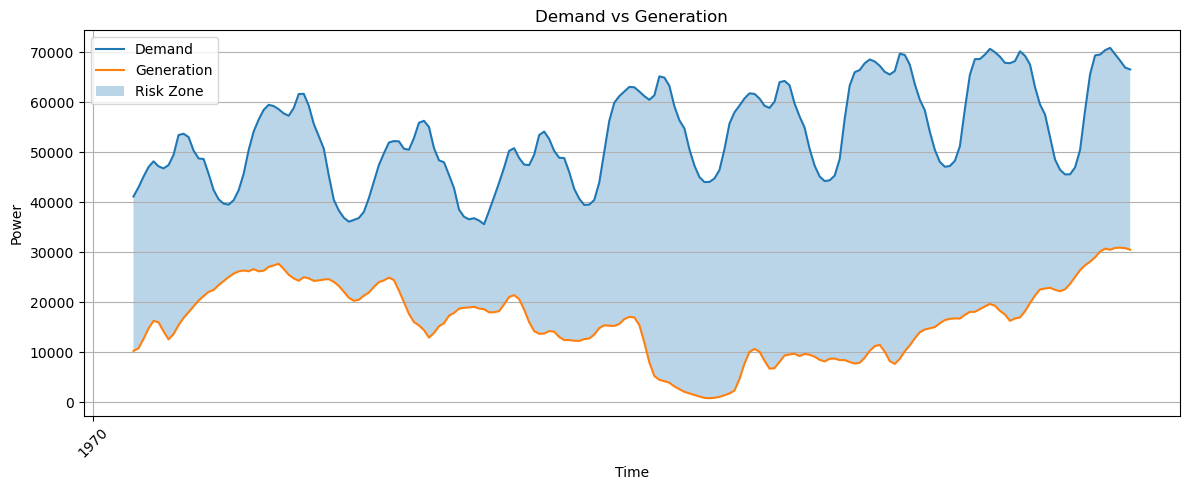

In [16]:
import matplotlib.pyplot as plt

period = risk_df.iloc[:200]

plt.figure(figsize=(12, 5))
plt.plot(period.index, period["DE_load_actual_entsoe_transparency"], label="Demand")
plt.plot(period.index, period["DE_total_generation"], label="Generation")
plt.fill_between(
    period.index,
    period["DE_load_actual_entsoe_transparency"],
    period["DE_total_generation"],
    where=period["risk_flag"],
    alpha=0.3,
    label="Risk Zone"
)

plt.title("Demand vs Generation")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()